# HFR Calibration — Static Model

This notebook calibrates the undetermined physical parameters of the 1D static PEMFC model by fitting the simulated High-Frequency Resistance (HFR) to experimental measurements across 12 operating conditions (temperature, pressure, humidity).

## Setup

Import external libraries and configure the project path so that custom modules (`model`, `configuration`) can be resolved.

In [4]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
import model.static as static_module
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

## Load experimental HFR data

Load all sheets from the HFR Excel file. Each sheet corresponds to one operating condition, named as `T{°C}_P{mbar}_HRC{%}`.

In [6]:
hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata = pd.read_excel(hfr_data_path, sheet_name=None)

### Extract operating conditions

Parse each sheet name to extract temperature, pressure, and humidity. Build a `conditions` dict where each entry contains:
- `operating_inputs`: a dict compatible with `PEMFC_stat` (keys: `Tfc`, `Pa_des`, `Pc_des`, `Phi_a_des`, `Phi_c_des`, `Win/Wout`)
- `data`: a clean DataFrame with columns `I_LOAD` (A) and `R` (mΩ, full stack)

In [7]:
conditions = {}
for sheet_name, data in hfr_testdata.items():
    parts = sheet_name.split("_")
    Tref = float(parts[0].removeprefix("T")) + 273.15       # °C → K
    Pref = (float(parts[1].removeprefix("P")) / 1e3 + 1) * 1e5      # mbar gauge → Pa abs
    HRref = float(parts[2].removeprefix("HRC")) / 100       # % → fraction

    oi = operating_inputs.copy()
    oi['Tfc'] = Tref
    oi['Pa_des'] = Pref       # Pa
    oi['Pc_des'] = Pref       # Pa
    oi['Phi_a_des'] = HRref
    oi['Phi_c_des'] = HRref
    oi['Win_c'] = 4.8
    oi['Wout_c'] = 21
    oi['Win_a'] = 4.8
    oi['Wout_a'] = 4.8

    # Parse the R column: string "(R_value, I_value)" → extract R as float
    parsed = data['R'].str.strip('()').str.split(',', expand=True).astype(float)
    df = pd.DataFrame({'I_LOAD': data['I_LOAD'], 'R': parsed[0]})

    conditions[sheet_name] = {'operating_inputs': oi, 'data': df}

## Parameter calibration

### Define search space

Define the hyperopt search space for 9 undetermined physical parameters with uniform priors over physically plausible ranges.

In [8]:
params_region = {}
params_region["Re"] = hp.uniform('Re', 1e-7, 5e-6)
params_region['epsilon_gdl'] = hp.uniform('epsilon_gdl', 0.5, 0.8)
params_region['epsilon_mc'] = hp.uniform('epsilon_mc', 0.15, 0.4)
params_region['epsilon_cl'] = hp.uniform('epsilon_cl', 0.1, 0.4)
params_region['epsilon_c'] = hp.uniform('epsilon_c', 0.2, 0.3)
params_region['tau'] = hp.uniform('tau', 1.0, 4.0)
params_region['Hgdl'] = hp.uniform('Hgdl', 2e-4, 4e-4)
params_region['Hcl'] = hp.uniform('Hcl', 1.e-5, 2e-5)
params_region["Wout_c"] = hp.uniform('Wout_c', 7, 22)
params_region["Wout_a"] = hp.uniform('Wout_a', 5, 8)

### Define objective function

The objective function `obj(params)` computes the sum of squared errors (SSE) between the model-predicted $R_{ohm}$ and the experimental HFR across all 12 conditions and 7 current points (10–50 A). For each condition, the module-level `Pa_des`/`Pc_des` globals are updated before calling `PEMFC_stat.solve()`.

In [9]:
def obj(params):
    # Update undetermined physical parameters
    for key in params:
        if "Wout" not in key:
            parameters[key] = params[key]

    Aact = parameters['Aact']
    n_cell = parameters['n_cell'] if 'n_cell' in parameters else 22

    error_sum = 0
    I_points = [10, 20, 30, 35, 40, 45, 50]
    for cond_name, cond in conditions.items():
        oi = cond['operating_inputs']
        oi["Wout_c"] = params['Wout_c']
        oi["Wout_a"] = params['Wout_a']
        df = cond['data']

        # Update module-level globals for Pa_des / Pc_des
        static_module.Pa_des = oi['Pa_des']
        static_module.Pc_des = oi['Pc_des']

        model = PEMFC_stat(parameters, oi)
        for I_LOAD in I_points:
            try:
                sol = model.solve(I_LOAD / Aact)
            except Exception:
                error_sum += 1e6
                continue
            R_pred = sol['Rohm']                                    # Ω·m²
            # R_exp: mΩ (full stack) → Ω·m² per cell = R * 1e-3 / n_cell * Aact
            idx = (df['I_LOAD'] - I_LOAD).abs().idxmin()
            R_exp = df.loc[idx, 'R'] * 1e-3 / n_cell * Aact        # Ω·m²
            error_sum += (R_pred - R_exp) ** 2
    return error_sum

### Evaluate initial error

Evaluate the objective function with the default (initial) parameter values to establish a baseline SSE before optimization.

In [10]:
# Test with initial (default) parameters
initial_params = {}
for key in params_region:
    if "Wout" not in key:
        initial_params[key] = parameters[key]
    else:
        initial_params[key] = 6.66

initial_error = obj(initial_params)

### Run hyperopt optimization

Use the Tree-structured Parzen Estimator (TPE) algorithm from `hyperopt` to search for the parameter set that minimizes the HFR SSE.

In [11]:
# Run hyperopt search
trials = Trials()
best = fmin(fn=obj, space=params_region, algo=tpe.suggest, max_evals=2000, trials=trials)

100%|██████████| 2000/2000 [26:37<00:00,  1.25trial/s, best loss: 1.4919247259969877e-10]


In [12]:
for param_opt in best:
    print(f"{param_opt}: {best[param_opt]:.6e}")

Hcl: 1.216794e-05
Hgdl: 3.596514e-04
Re: 4.301981e-06
Wout_a: 5.227445e+00
Wout_c: 7.001415e+00
epsilon_c: 2.556665e-01
epsilon_cl: 1.002167e-01
epsilon_gdl: 6.544564e-01
epsilon_mc: 3.834943e-01
tau: 2.771358e+00


## Results

### Plot fitting results

Apply the best parameters and simulate HFR over a dense current range for each of the 12 operating conditions. Plot model predictions (solid lines) against experimental data (open circles) in a 3×4 grid.

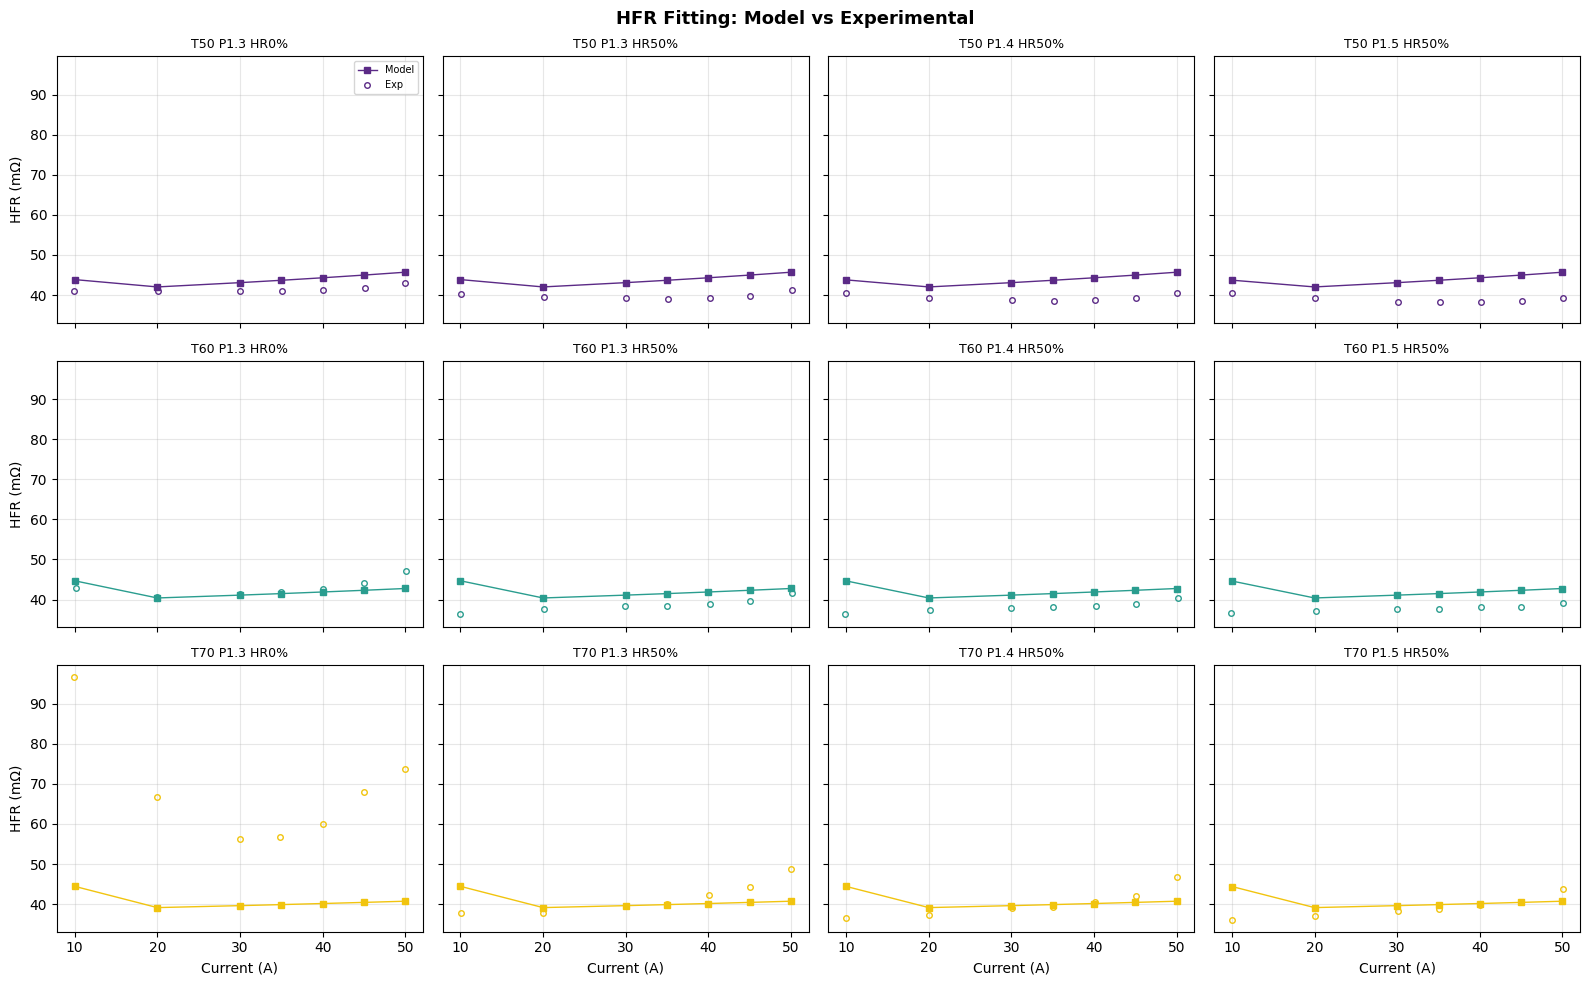

In [13]:
# Apply best parameters
for key in best:
    parameters[key] = best[key]

Aact = parameters['Aact']
I_points = [10, 20, 30, 35, 40, 45, 50]

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (cond_name, cond) in enumerate(conditions.items()):
    ax = axes[idx]
    oi = cond['operating_inputs']
    df = cond['data']

    # Parse condition label
    parts = cond_name.split("_")
    T_val = float(parts[0].removeprefix("T"))
    P_val = float(parts[1].removeprefix("P")) / 1e3 + 1
    HR_val = float(parts[2].removeprefix("HRC"))

    # Update module-level globals
    static_module.Pa_des = oi['Pa_des']
    static_module.Pc_des = oi['Pc_des']

    # Simulate at the same 7 current points
    model = PEMFC_stat(parameters, oi)
    R_sim = []
    I_valid = []
    for I in I_points:
        try:
            sol = model.solve(I / Aact)
            R_sim.append(sol['Rohm'] / Aact * n_cell * 1e3)  # Ω·m² → mΩ (stack)
            I_valid.append(I)
        except Exception:
            continue

    # Plot
    color = temp_colors.get(T_val, "0.35")
    ax.plot(I_valid, R_sim, 's-', color=color, linewidth=1, markersize=5, label='Model')
    ax.plot(df['I_LOAD'], df['R'], 'o', color=color, markersize=4, markerfacecolor='none', label='Exp')
    ax.set_title(f"T{T_val:.0f} P{P_val:.1f} HR{HR_val:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx >= 8:
        ax.set_xlabel("Current (A)")
    if idx % 4 == 0:
        ax.set_ylabel("HFR (mΩ)")

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle("HFR Fitting: Model vs Experimental", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()